# YOLO 외 객체검출 모델 비교 — RF-DETR · RT-DETR (Web Cam)

- **목적**: YOLO 외 모델 중 우리 프로젝트에 가장 권장되는 2가지(`docs/notion_draft/detector_survey_wc.md` 추천 1·2순위)를
  **YOLO 비교 실험과 같은 데이터·같은 절차·같은 평가 기준**으로 학습하고 비교한다.
  - **RF-DETR** (Roboflow, 2025): DINOv2 backbone + DETR, NMS 없음, 소량 데이터 fine-tuning에 강하도록 설계 → Nano / Small
  - **RT-DETR** (Baidu, 2023, Ultralytics 내장): 최초의 실시간 DETR, NMS 없음 → l / x (Ultralytics에서 제공하는 크기는 이 둘뿐)
- **데이터셋**: `../data_wc/rokey_mp4_a1.v2i.yolo26` (Roboflow v2, 640x640, train 444 / valid 43 / test 21) — YOLO 실험과 동일
- **결과 저장 위치**: `./result_detection/` (YOLO 노트북과 같은 구조)
- **비교 기준선**: YOLO 실험에서 선정한 **YOLO26n**(`../03_YOLO_v8_object_detection/result_detection/exp1_models/yolo26n`)을 이 노트북의 평가 코드로 **똑같이 다시 평가**해서 함께 싣는다

| 실험 | 내용 | 학습 횟수 |
|---|---|---|
| 실험 1 | 모델별 비교: 4개 모델, 각 라이브러리 기본 증강 | 4 |
| 실험 2 | augmentation 개수별 비교: 4개 모델 x 증강 3조건 (`aug0` / `aug2` / `aug4`) | 12 |

**실행 순서**: 위에서부터 차례대로 실행. 먼저 `QUICK_TEST = True`로 끝까지 도는지 확인한 뒤 `False`로 본 실험을 한다.

## 0. 패키지 확인
RF-DETR은 `rfdetr` 패키지를 쓴다. ⚠️ 이 venv는 ROS(cv_bridge)와 같이 쓰므로 **numpy·opencv 버전을 바꾸지 않게** 설치했다.
- `rfdetr`, `rfdetr[train]`의 학습 의존성, `albumentations`(사용자 증강용)를 `--no-deps`로 설치 (opencv-python-headless 제외)
- 평가에는 `pycocotools`(COCO 공식 mAP 계산)를 쓴다

In [1]:
import importlib
for pkg in ['ultralytics', 'rfdetr', 'albumentations', 'pycocotools', 'pytorch_lightning', 'numpy', 'cv2', 'torch']:
    m = importlib.import_module(pkg)
    print(f'{pkg:18s}', getattr(m, '__version__', ''))

ultralytics        8.4.170


/home/mu-01/venvs/rokey_venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/mu-01/venvs/rokey_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mu-01/venvs/rokey_venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


rfdetr             
albumentations     2.0.8
pycocotools        


pytorch_lightning  2.6.6
numpy              1.26.4
cv2                4.9.0
torch              2.14.1+cu130


## 1. 설정
- ⚠️ **`QUICK_TEST`**: `True`면 1 epoch(RT-DETR은 데이터 10%)만 학습해서 코드가 끝까지 도는지만 확인한다. 결과는 `result_detection/_quick_test/`에 따로 저장된다.
- **학습 조건은 YOLO 실험과 같게** 맞춘다: `EPOCHS = 100`, 개선 없이 `PATIENCE = 20` epoch이면 조기 종료, batch 16
  - RT-DETR: `batch=4`, `imgsz=640`. ⚠️ 이 PC(RTX 4070 Laptop 8GB)에서 rtdetr-x는 batch 8에서도 메모리가 부족하고(퀵테스트: Ultralytics가 batch를 자동으로 줄임),
    rtdetr-l은 8이 한계(6.7GB)였다. 그래서 **모든 RT-DETR run을 4로 통일**했다 — RF-DETR의 한 번에 넣는 batch(4)와도 같다.
    Ultralytics는 batch와 상관없이 **gradient를 64장(`nbs=64`)만큼 모아서 한 번 갱신**하므로, 가중치 갱신 단위는 YOLO 실험(batch 16)과 같다
  - RF-DETR: `batch_size=4` x `grad_accum_steps=4` = **실효 batch 16** (RF-DETR 공식 권장 방식). 입력 해상도는 **모델 고유값**(Nano 384, Small 512)을 쓴다
    — RF-DETR은 이 해상도로 설계·사전학습되어 있고, 공개된 속도·정확도도 이 해상도 기준이다

In [2]:
import os
import time
import json
import logging
from pathlib import Path

QUICK_TEST = False       # ⚠️ 동작 확인 후 False로 바꿔 본 실험 진행
BATCH = 4                # ⚠️ RT-DETR batch. 8GB GPU에서 rtdetr-x가 들어가는 최대값 4로 모든 RT-DETR run 통일 (아래 설명)
RF_BATCH, RF_ACCUM = 4, 4  # RF-DETR: 4 x 4 = 실효 batch 16
EPOCHS = 100
PATIENCE = 20            # 20 epoch 동안 개선이 없으면 조기 종료
IMGSZ = 640

# 모든 표·그래프는 이 순서로 나온다: 최신 모델부터 (같은 계열 안에서는 작은 모델 → 큰 모델)
MODEL_LIST = ['rfdetr-n', 'rfdetr-s', 'rtdetr-l', 'rtdetr-x']
REF_MODEL = 'yolo26n'    # 비교 기준선 (YOLO 실험 선정 모델, 학습하지 않고 평가만)

# 경로 (노트북이 있는 폴더 기준)
NB_DIR = Path.cwd()
DATA_DIR = (NB_DIR / '../data_wc/rokey_mp4_a1.v2i.yolo26').resolve()
REF_RUN = (NB_DIR / '../03_YOLO_v8_object_detection/result_detection/exp1_models' / REF_MODEL).resolve()
RESULT_DIR = NB_DIR / 'result_detection'
if QUICK_TEST:
    RESULT_DIR = RESULT_DIR / '_quick_test'
PRETRAINED_DIR = NB_DIR / 'result_detection' / 'pretrained'   # RT-DETR COCO 사전학습 가중치
LOG_DIR = RESULT_DIR / 'log'
for d in [RESULT_DIR, PRETRAINED_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

assert (DATA_DIR / 'train/images').is_dir(), f'데이터셋 경로 확인: {DATA_DIR}'
assert (REF_RUN / 'weights/best.pt').is_file(), f'기준선 YOLO26n 경로 확인: {REF_RUN}'

# 사전학습 가중치(rtdetr-l.pt 등)가 노트북 폴더에 흩어지지 않게 작업 폴더를 옮긴다
# (RF-DETR 가중치는 ~/.roboflow/models/ 에 자동 저장됨)
os.chdir(PRETRAINED_DIR)

# Ultralytics, RF-DETR log를 파일로도 남긴다 (학습 과정 기록)
TS = time.strftime('%y%m%d_%H%M%S')
log_path = LOG_DIR / f'log_{TS}.txt'
for name in ['ultralytics', 'rf-detr']:
    logging.getLogger(name).addHandler(logging.FileHandler(log_path, encoding='utf-8'))

print('QUICK_TEST :', QUICK_TEST)
print('DATA_DIR   :', DATA_DIR)
print('REF_RUN    :', REF_RUN)
print('RESULT_DIR :', RESULT_DIR)
print('log        :', log_path)

QUICK_TEST : False
DATA_DIR   : /home/mu-01/ROKEY_mP4_A1/wc/data_wc/rokey_mp4_a1.v2i.yolo26
REF_RUN    : /home/mu-01/ROKEY_mP4_A1/wc/03_YOLO_v8_object_detection/result_detection/exp1_models/yolo26n
RESULT_DIR : /home/mu-01/ROKEY_mP4_A1/wc/05_non_YOLO_object_detection/result_detection
log        : /home/mu-01/ROKEY_mP4_A1/wc/05_non_YOLO_object_detection/result_detection/log/log_261006_142157.txt


## 2. 데이터셋 yaml 만들기
- RT-DETR(Ultralytics): Roboflow의 `data.yaml`은 상대 경로라서, 절대 경로로 된 `custom_data.yaml`을 `result_detection/`에 새로 만든다.
- RF-DETR: YOLO 형식 데이터셋 폴더(`data.yaml` + `train/valid/test`)를 **그대로** 읽는다. 변환 없음

In [3]:
import yaml

with open(DATA_DIR / 'data.yaml') as f:
    roboflow_yaml = yaml.safe_load(f)

data = {
    'train': str(DATA_DIR / 'train/images'),
    'val': str(DATA_DIR / 'valid/images'),
    'test': str(DATA_DIR / 'test/images'),
    'nc': roboflow_yaml['nc'],
    'names': roboflow_yaml['names'],
}
DATA_YAML = RESULT_DIR / 'custom_data.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print(open(DATA_YAML).read())

names:
- car
- dummy
nc: 2
test: /home/mu-01/ROKEY_mP4_A1/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/images
train: /home/mu-01/ROKEY_mP4_A1/wc/data_wc/rokey_mp4_a1.v2i.yolo26/train/images
val: /home/mu-01/ROKEY_mP4_A1/wc/data_wc/rokey_mp4_a1.v2i.yolo26/valid/images



## 3. 데이터 확인
split별 이미지 수와 class별 객체 수, 그리고 train 이미지 몇 장을 라벨 박스와 함께 본다. (YOLO 실험과 같은 데이터)

train: 이미지 444장, 객체 {'car': 369, 'dummy': 375}
valid: 이미지  43장, 객체 {'car': 36, 'dummy': 35}
test : 이미지  21장, 객체 {'car': 21, 'dummy': 16}


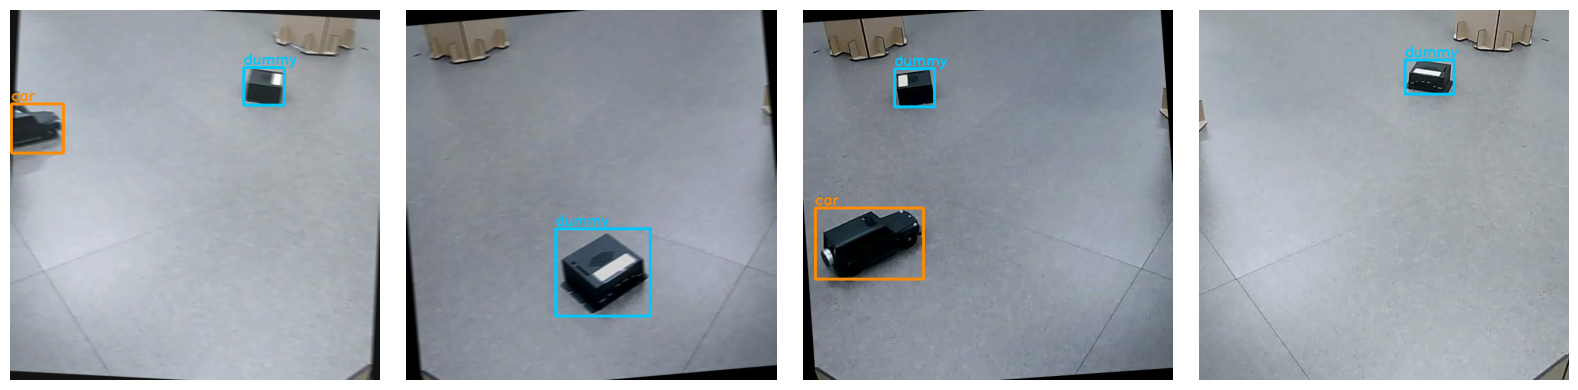

In [4]:
%matplotlib inline
import random
import cv2
import matplotlib.pyplot as plt

names = data['names']
for split in ['train', 'valid', 'test']:
    images = sorted((DATA_DIR / split / 'images').glob('*.jpg'))
    counts = {n: 0 for n in names}
    for img in images:
        label = DATA_DIR / split / 'labels' / (img.stem + '.txt')
        for line in label.read_text().splitlines():
            if line.strip():
                counts[names[int(line.split()[0])]] += 1
    print(f'{split:5s}: 이미지 {len(images):3d}장, 객체 {counts}')

# train 이미지 4장을 라벨 박스와 함께 표시
random.seed(0)
samples = random.sample(sorted((DATA_DIR / 'train/images').glob('*.jpg')), 4)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img_path in zip(axes, samples):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    label = DATA_DIR / 'train/labels' / (img_path.stem + '.txt')
    for line in label.read_text().splitlines():
        if not line.strip():
            continue
        c, cx, cy, bw, bh = map(float, line.split())
        x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
        x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
        color = (255, 140, 0) if names[int(c)] == 'car' else (0, 200, 255)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img, names[int(c)], (x1, max(y1 - 6, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. 공통 함수
두 계열(RF-DETR, Ultralytics RT-DETR)과 기준선 YOLO26n을 **같은 함수로 학습·추론·평가**하기 위한 함수들.
- `train_run()`: 학습 1회. 결과 폴더에 best 가중치가 이미 있으면 건너뛴다 (중간에 끊겨도 이어서 실행 가능)
  - run마다 **별도 프로세스**에서 학습한다 (GPU 메모리를 run마다 완전히 비우기 위함). 학습 출력은 `log/train_<run>.txt`
  - Ultralytics가 메모리 부족으로 batch를 자동으로 줄이면 **멈추고 알린다** (run마다 batch가 달라지면 공정 비교가 안 되므로)
- `Detector`: 모델 종류와 상관없이 `이미지(BGR) → [(class, conf, [x1, y1, x2, y2])]`를 돌려주는 공통 추론기
- `coco_eval()`: **pycocotools(COCO 공식 코드)** 로 mAP50 / mAP50-95와 class별 AP를 계산 — 모든 모델(기준선 YOLO26n 포함)을 같은 코드로 채점
- `match()`: 같은 class의 정답과 IoU≥0.5 일대일 매칭 (YOLO 실험 8번과 같은 함수)
- `history()`: 학습 log에서 epoch별 Val mAP를 읽어 best epoch, 학습 시간을 구한다

In [5]:
import gc
import contextlib
import io
import subprocess
import sys
import numpy as np
import pandas as pd
import torch
from PIL import Image
from ultralytics import RTDETR, YOLO
from rfdetr import RFDETRNano, RFDETRSmall
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

RFDETR_CLASS = {'rfdetr-n': RFDETRNano, 'rfdetr-s': RFDETRSmall}
CONF_TEST, NMS_IOU, MATCH_IOU = 0.25, 0.7, 0.5
CONF_MAP = 0.001         # mAP 계산용 (Ultralytics val과 같은 낮은 conf)


def is_rfdetr(model_name):
    return model_name.startswith('rfdetr')


def best_weights(model_name, run_dir):
    return run_dir / ('checkpoint_best_total.pth' if is_rfdetr(model_name) else 'weights/best.pt')


def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()


def train_run(model_name, project_dir, run_name, aug_args=None):
    # 학습 1회. 이미 끝난 run은 건너뛰고 best 가중치 경로를 돌려준다.
    # ⚠️ 학습은 run마다 **별도 프로세스**에서 한다. 한 kernel에서 여러 모델을 연달아 학습하면 GPU 메모리가 다 풀리지 않아
    #    RT-DETR이 메모리 부족을 내고, 이때 Ultralytics가 batch를 16 → 8 → 4로 몰래 줄여 run마다 batch가 달라진다 (퀵테스트에서 확인)
    run_dir = project_dir / run_name
    best = best_weights(model_name, run_dir)
    if best.exists():
        print('이미 완료, 건너뜀:', run_name)
        return best

    print('========== 학습 시작:', run_name)
    if is_rfdetr(model_name):
        args = dict(dataset_dir=str(DATA_DIR), output_dir=str(run_dir), epochs=EPOCHS,
                    batch_size=RF_BATCH, grad_accum_steps=RF_ACCUM, num_workers=4, seed=0,
                    early_stopping=True, early_stopping_patience=PATIENCE, early_stopping_min_delta=0.0,
                    early_stopping_use_ema=True, progress_bar=None, tensorboard=False)
        if QUICK_TEST:
            args.update(epochs=1)
        args.update(aug_args or {})
        code = f'from rfdetr import {RFDETR_CLASS[model_name].__name__} as M\nM().train(**{args!r})'
    else:
        args = dict(data=str(DATA_YAML), epochs=EPOCHS, patience=PATIENCE, batch=BATCH, imgsz=IMGSZ,
                    project=str(project_dir), name=run_name, exist_ok=True)
        if QUICK_TEST:
            args.update(epochs=1, fraction=0.1)
        args.update(aug_args or {})
        # PRETRAINED_DIR에 없으면 사전학습 가중치 자동 다운로드
        code = f'from ultralytics import RTDETR\nRTDETR({model_name + ".pt"!r}).train(**{args!r})'

    run_log = LOG_DIR / f'train_{run_name}.txt'
    t0 = time.time()
    with open(run_log, 'w') as f:
        ret = subprocess.run([sys.executable, '-c', code], cwd=PRETRAINED_DIR, stdout=f, stderr=subprocess.STDOUT)
    train_sec = time.time() - t0
    out = run_log.read_text(encoding='utf-8', errors='ignore')
    with open(log_path, 'a', encoding='utf-8') as f:     # 전체 log에도 이어 붙인다 (optimizer 줄 확인용)
        f.write(f'\n===== {run_name} =====\n' + out)
    if ret.returncode != 0 or not best.exists():
        raise RuntimeError(f'학습 실패: {run_name} → {run_log} 확인')
    if 'Reducing to batch' in out:
        raise RuntimeError(f'{run_name}: GPU 메모리 부족으로 batch가 자동으로 줄었음 (공정 비교 불가) → {run_log} 확인')
    # 학습 시간(초)을 남긴다 (RF-DETR은 results.csv에 시간이 없어서 같은 방식으로 통일)
    (run_dir / 'train_time_sec.txt').write_text(f'{train_sec:.1f}\n')
    print(f'저장 완료: {run_name} ({train_sec / 60:.1f}분)')
    return best


class Detector:
    # 모델 종류와 상관없이 같은 방식으로 추론한다. 입력: BGR 이미지(np.ndarray)
    def __init__(self, model_name, weights):
        self.rf = is_rfdetr(model_name)
        if self.rf:
            self.model = RFDETR_CLASS[model_name](pretrain_weights=str(weights), num_classes=len(names))
            self.model.inference(compile=False)   # 학습용 부분을 떼어낸 추론 모드 (FP32, 컴파일 없음)
        elif model_name.startswith('rtdetr'):
            self.model = RTDETR(str(weights))
        else:
            self.model = YOLO(str(weights))

    def __call__(self, bgr, conf):
        if self.rf:
            d = self.model.predict(bgr[:, :, ::-1].copy(), threshold=conf)   # RF-DETR은 RGB 입력
            return [(int(c), float(s), b.tolist()) for c, s, b in zip(d.class_id, d.confidence, d.xyxy)]
        r = self.model.predict(bgr, conf=conf, iou=NMS_IOU, imgsz=IMGSZ, verbose=False)[0]
        self.last_speed = r.speed    # Ultralytics가 잰 구간별 시간 (전처리 / 추론 / 후처리)
        return [(int(c), float(s), b.tolist()) for c, s, b in
                zip(r.boxes.cls.cpu(), r.boxes.conf.cpu(), r.boxes.xyxy.cpu())]

    def timed(self, bgr, conf):
        # 전처리부터 후처리까지 한 장 처리 시간(ms). GPU 작업이 끝날 때까지 기다린 뒤 잰다
        torch.cuda.synchronize()
        t = time.perf_counter()
        out = self(bgr, conf)
        torch.cuda.synchronize()
        return out, (time.perf_counter() - t) * 1000


def load_gt(img_path, w, h):
    # YOLO 라벨(정규화 xywh)을 픽셀 xyxy로 바꾼다
    gt = []
    for line in (img_path.parent.parent / 'labels' / (img_path.stem + '.txt')).read_text().splitlines():
        if line.strip():
            c, cx, cy, bw, bh = map(float, line.split())
            gt.append((int(c), [(cx - bw / 2) * w, (cy - bh / 2) * h, (cx + bw / 2) * w, (cy + bh / 2) * h]))
    return gt


def box_iou(a, b):
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


def match(preds, gts):
    # 같은 class끼리 IoU 큰 쌍부터 일대일 매칭. preds: [(cls, conf, box)], gts: [(cls, box)]
    pairs = sorted(((box_iou(p[2], g[1]), i, j) for i, p in enumerate(preds) for j, g in enumerate(gts)
                    if p[0] == g[0]), reverse=True)
    used_p, used_g, tp = set(), set(), []
    for iou, i, j in pairs:
        if iou < MATCH_IOU:
            break
        if i not in used_p and j not in used_g:
            used_p.add(i); used_g.add(j); tp.append((i, j, iou))
    return tp, used_p, used_g


# split별 이미지를 메모리에 올려 둔다 (디스크 읽기 시간이 처리 시간에 섞이지 않게)
IMAGES = {}
for split in ['valid', 'test']:
    IMAGES[split] = [(p, cv2.imread(str(p))) for p in sorted((DATA_DIR / split / 'images').glob('*.jpg'))]


def coco_eval(det, split):
    # pycocotools로 mAP를 계산한다. 반환: (요약 dict, class별 AP DataFrame, COCOeval, 예측 목록)
    gt = dict(images=[], annotations=[], categories=[{'id': i, 'name': n} for i, n in enumerate(names)])
    dets, preds_all = [], []
    for img_id, (p, bgr) in enumerate(IMAGES[split]):
        h, w = bgr.shape[:2]
        gt['images'].append(dict(id=img_id, width=w, height=h, file_name=p.name))
        for c, b in load_gt(p, w, h):
            gt['annotations'].append(dict(id=len(gt['annotations']) + 1, image_id=img_id, category_id=c,
                                          bbox=[b[0], b[1], b[2] - b[0], b[3] - b[1]],
                                          area=(b[2] - b[0]) * (b[3] - b[1]), iscrowd=0))
        preds = det(bgr, CONF_MAP)
        preds_all.append(preds)
        for c, s, b in preds:
            dets.append(dict(image_id=img_id, category_id=c, score=s, bbox=[b[0], b[1], b[2] - b[0], b[3] - b[1]]))
    with contextlib.redirect_stdout(io.StringIO()):
        cg = COCO(); cg.dataset = gt; cg.createIndex()
        cd = cg.loadRes(dets) if dets else COCO()
        E = COCOeval(cg, cd, 'bbox')
        E.evaluate(); E.accumulate(); E.summarize()
    prec = E.eval['precision']          # [IoU 10, recall 101, class, area, maxDets]
    rows = []
    for k, n in enumerate(names):
        pk = prec[:, :, k, 0, -1]
        ap = float(np.mean(pk[pk > -1])) if (pk > -1).any() else 0.0
        p50 = prec[0, :, k, 0, -1]
        ap50 = float(np.mean(p50[p50 > -1])) if (p50 > -1).any() else 0.0
        rows.append(dict(**{'class': n}, AP50=round(ap50, 4), **{'AP50-95': round(ap, 4)}))
    return dict(mAP50=E.stats[1], mAP50_95=E.stats[0]), pd.DataFrame(rows), E, preds_all


def history(model_name, run_dir):
    # epoch별 Val mAP50-95 → (best epoch, 마지막 epoch, best epoch의 Val mAP50, mAP50-95, 학습 분)
    if is_rfdetr(model_name):
        m = pd.read_csv(run_dir / 'metrics.csv')
        m = m[m['val/mAP_50_95'].notna()].reset_index(drop=True)
        # RF-DETR은 일반 가중치와 EMA 가중치 중 더 좋은 쪽을 best로 저장한다 → 둘 중 큰 값
        s95 = np.maximum(m['val/mAP_50_95'], m['val/ema_mAP_50_95'])
        s50 = np.where(m['val/ema_mAP_50_95'] >= m['val/mAP_50_95'], m['val/ema_mAP_50'], m['val/mAP_50'])
    else:
        m = pd.read_csv(run_dir / 'results.csv')
        s95, s50 = m['metrics/mAP50-95(B)'].values, m['metrics/mAP50(B)'].values
    i = int(np.argmax(s95))
    tfile = run_dir / 'train_time_sec.txt'
    if tfile.exists():
        train_min = float(tfile.read_text()) / 60
    else:   # 기준선 YOLO26n: YOLO 노트북의 results.csv 시간
        train_min = m['time'].iloc[-1] / 60
    return i + 1, len(m), float(s50[i]), float(s95[i]), round(train_min, 2)


def evaluate(model_name, run_dir, **extra):
    # best 가중치로 valid를 다시 평가하고 비교표 한 줄을 만든다 (모든 모델 같은 코드)
    det = Detector(model_name, best_weights(model_name, run_dir))
    summ, _, _, preds_all = coco_eval(det, 'valid')
    tp = fp = fn = 0
    for (p, bgr), preds in zip(IMAGES['valid'], preds_all):
        h, w = bgr.shape[:2]
        gts = load_gt(p, w, h)
        keep = [x for x in preds if x[1] >= CONF_TEST]
        t, up, ug = match(keep, gts)
        tp += len(t); fp += len(keep) - len(up); fn += len(gts) - len(ug)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    for _ in range(5):                                   # 워밍업
        det.timed(IMAGES['valid'][0][1], CONF_TEST)
    ms = [det.timed(bgr, CONF_TEST)[1] for _, bgr in IMAGES['valid']]
    best_ep, last_ep, _, _, train_min = history(model_name, run_dir)
    row = dict(extra)
    row.update({
        'epochs': last_ep,
        'train_min': round(train_min, 1),
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'F1': round(f1, 3),
        'mAP50': round(summ['mAP50'], 3),
        'mAP50-95': round(summ['mAP50_95'], 3),
        'total_ms': round(float(np.mean(ms)), 1),
    })
    del det
    free_gpu()
    return row

## 5. 실험 1 — 모델별 비교 (각 라이브러리 기본 증강)
- RF-DETR 기본 증강: 좌우 반전(50%) + 무작위 크기 변경(multi-scale) + 무작위 crop 후 resize(scale jitter)
- RT-DETR 기본 증강: Ultralytics 기본값 (YOLO 실험 1과 같음: mosaic, 밝기·색, 이동, 크기, 좌우 반전 등)

결과: `result_detection/exp1_models/<모델>/` (RF-DETR: `checkpoint_best_total.pth`, `metrics.csv` / RT-DETR: `weights/best.pt`, `results.csv`)

비교표의 P / R / F1은 **valid에서 conf 0.25, IoU 0.5 일대일 매칭**으로, `total_ms`는 **전처리~후처리 한 장 처리 시간**으로 모든 모델을 같은 코드로 잰다.
맨 아래 줄은 기준선 YOLO26n이다.

In [6]:
EXP1_DIR = RESULT_DIR / 'exp1_models'

for model_name in MODEL_LIST:
    train_run(model_name, EXP1_DIR, model_name)

이미 완료, 건너뜀: rfdetr-n
이미 완료, 건너뜀: rfdetr-s
이미 완료, 건너뜀: rtdetr-l
이미 완료, 건너뜀: rtdetr-x


[2026-10-06 14:21:57] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-06 14:21:57] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


========== 평가: rfdetr-n


[2026-10-06 14:22:00] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-06 14:22:00] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


...

========== 평가: rtdetr-l


========== 평가: rtdetr-x


========== 평가 (기준선): yolo26n


,model,epochs,train_min,precision,recall,F1,mAP50,mAP50-95,total_ms
0,rfdetr-n,60,12.5,1.000,1.0,1.000,1.000,0.953,9.6
1,rfdetr-s,32,10.0,0.986,1.0,0.993,1.000,0.950,14.6
2,rtdetr-l,68,24.2,0.887,1.0,0.940,0.999,0.956,19.5
3,rtdetr-x,38,19.5,0.345,1.0,0.513,1.000,0.947,28.8
4,yolo26n (기준선),100,4.5,0.973,1.0,0.986,1.000,0.959,5.2


/tmp/ipykernel_560414/3840981400.py:22: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_560414/3840981400.py:22: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_560414/3840981400.py:22: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_560414/3840981400.py:23: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.savefig(RESULT_DIR / 'compare_models.png')
/tmp/ipykernel_560414/3840981400.py:23: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from current font.
  plt.savefig(RESULT_DIR / 'compare_models.png')
/tmp/ipykernel_560414/3840981400.py:23: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from current font.
  plt.savefig(RESULT_DIR / 'compare_models.png')
/home/mu-01/venvs/rokey_venv/lib/python3.12/site-packages/IPython/core/pylabtools.

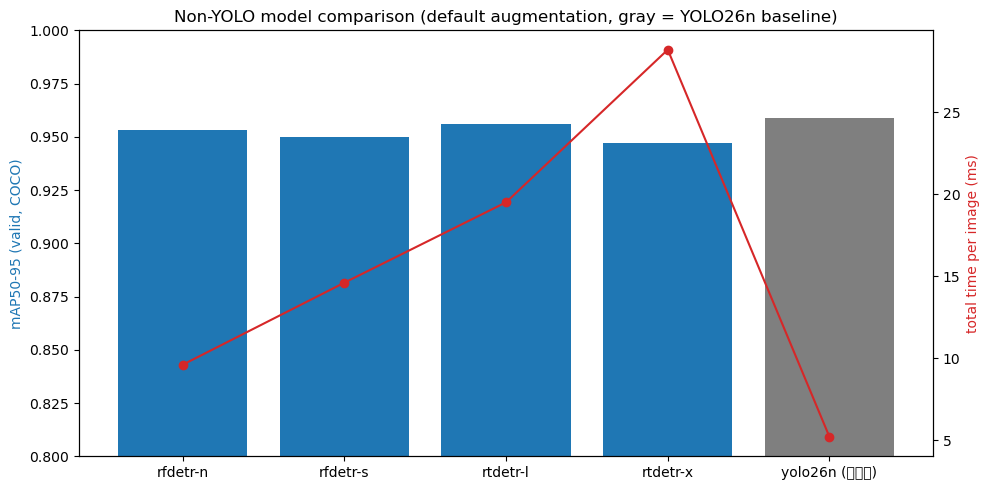

저장: /home/mu-01/ROKEY_mP4_A1/wc/05_non_YOLO_object_detection/result_detection/compare_models.csv


In [7]:
rows = []
for model_name in MODEL_LIST:
    print('========== 평가:', model_name)
    rows.append(evaluate(model_name, EXP1_DIR / model_name, model=model_name))
print('========== 평가 (기준선):', REF_MODEL)
rows.append(evaluate(REF_MODEL, REF_RUN, model=REF_MODEL + ' (기준선)'))

table1 = pd.DataFrame(rows)
display(table1)
table1.to_csv(RESULT_DIR / 'compare_models.csv', index=False)

# mAP50-95와 처리 시간 그래프
fig, ax1 = plt.subplots(figsize=(10, 5))
colors = ['tab:blue'] * len(MODEL_LIST) + ['tab:gray']
ax1.bar(table1['model'], table1['mAP50-95'], color=colors)
ax1.set_ylabel('mAP50-95 (valid, COCO)', color='tab:blue')
ax1.set_ylim(0.8, 1.0)
ax2 = ax1.twinx()
ax2.plot(table1['model'], table1['total_ms'], 'o-', color='tab:red')
ax2.set_ylabel('total time per image (ms)', color='tab:red')
plt.title('Non-YOLO model comparison (default augmentation, gray = YOLO26n baseline)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'compare_models.png')
plt.show()
print('저장:', RESULT_DIR / 'compare_models.csv')

## 6. 실험 2 — augmentation 개수별 비교
YOLO 실험 2와 같은 **4가지 증강(mosaic, 밝기, 이동, 크기)** 을 0개 / 2개 / 4개 켠다. 나머지 증강은 모든 조건에서 끈다.

| 조건 | 켜는 증강 | RT-DETR (Ultralytics, YOLO와 동일) | RF-DETR (같은 효과의 설정) |
|---|---|---|---|
| `aug0` | 없음 | 모두 0 | `aug_config={}`, multi-scale·scale jitter 끔 |
| `aug2` | mosaic, 밝기 | `mosaic=1.0`, `hsv_v=0.4` | **scale jitter**(mosaic 대체), 밝기 ±40% |
| `aug4` | + 이동, 크기 | + `translate=0.1`, `scale=0.5` | + 이동 ±10%, 크기 0.5~1.5배 (`Affine`) |

> ⚠️ RF-DETR에는 **mosaic이 없다**. 가장 가까운 기본 기능인 **scale jitter(무작위 crop 후 resize — 한 장 안에서 물체 크기·위치·잘림을 바꿈)** 로 대체했다.
> 따라서 `aug2`의 첫 번째 증강은 두 계열에서 완전히 같지 않다.
> 참고: 데이터셋 자체에 Roboflow 증강(좌우 반전, 회전 ±5°, 밝기 ±15%, blur, 원본당 3장)이 이미 들어가 있다.

결과: `result_detection/exp2_aug/<모델>_<조건>/`

In [8]:
EXP2_DIR = RESULT_DIR / 'exp2_aug'

# RT-DETR (Ultralytics): YOLO 실험 2와 같은 값 (0.0 = 끔)
AUG_SETTINGS = {
    'aug0': {'mosaic': 0.0, 'hsv_v': 0.0, 'translate': 0.0, 'scale': 0.0},
    'aug2': {'mosaic': 1.0, 'hsv_v': 0.4, 'translate': 0.0, 'scale': 0.0},
    'aug4': {'mosaic': 1.0, 'hsv_v': 0.4, 'translate': 0.1, 'scale': 0.5},
}
# 아래 증강은 모든 조건에서 끔 (YOLO 실험 2와 같음)
AUG_OFF = dict(fliplr=0.0, flipud=0.0, hsv_h=0.0, hsv_s=0.0, degrees=0.0, shear=0.0,
               perspective=0.0, mixup=0.0, copy_paste=0.0)

# RF-DETR: 같은 효과의 설정 (Albumentations 증강 + RF-DETR 기본 기능 on/off)
BRIGHT = {'RandomBrightnessContrast': {'brightness_limit': 0.4, 'contrast_limit': 0.0, 'p': 1.0}}
AFFINE = {'Affine': {'translate_percent': [-0.1, 0.1], 'scale': [0.5, 1.5], 'p': 1.0}}
RF_AUG = {
    'aug0': dict(aug_config={}, multi_scale=False, scale_jitter=False),
    'aug2': dict(aug_config=BRIGHT, multi_scale=False, scale_jitter=True),
    'aug4': dict(aug_config={**BRIGHT, **AFFINE}, multi_scale=False, scale_jitter=True),
}

for model_name in MODEL_LIST:
    for aug_name in AUG_SETTINGS:
        aug_args = RF_AUG[aug_name] if is_rfdetr(model_name) else {**AUG_SETTINGS[aug_name], **AUG_OFF}
        train_run(model_name, EXP2_DIR, f'{model_name}_{aug_name}', aug_args)

이미 완료, 건너뜀: rfdetr-n_aug0
이미 완료, 건너뜀: rfdetr-n_aug2
이미 완료, 건너뜀: rfdetr-n_aug4
이미 완료, 건너뜀: rfdetr-s_aug0
이미 완료, 건너뜀: rfdetr-s_aug2
이미 완료, 건너뜀: rfdetr-s_aug4
이미 완료, 건너뜀: rtdetr-l_aug0
이미 완료, 건너뜀: rtdetr-l_aug2
이미 완료, 건너뜀: rtdetr-l_aug4
이미 완료, 건너뜀: rtdetr-x_aug0
이미 완료, 건너뜀: rtdetr-x_aug2
이미 완료, 건너뜀: rtdetr-x_aug4


[2026-10-06 14:22:09] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-06 14:22:09] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


========== 평가: rfdetr-n_aug0


[2026-10-06 14:22:10] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-06 14:22:10] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


...

========== 평가: rtdetr-x_aug0


========== 평가: rtdetr-x_aug2


========== 평가: rtdetr-x_aug4


,model,aug,epochs,train_min,precision,recall,F1,mAP50,mAP50-95,total_ms
0,rfdetr-n,aug0,40,8.1,0.986,1.0,0.993,1.000,0.951,8.9
1,rfdetr-n,aug2,38,9.5,0.973,1.0,0.986,1.000,0.961,9.7
2,rfdetr-n,aug4,43,10.1,0.973,1.0,0.986,1.000,0.944,9.6
3,rfdetr-s,aug0,41,12.1,0.986,1.0,0.993,1.000,0.961,13.2
4,rfdetr-s,aug2,97,28.5,0.986,1.0,0.993,1.000,0.968,13.0
5,rfdetr-s,aug4,86,25.5,0.973,1.0,0.986,1.000,0.959,13.0
6,rtdetr-l,aug0,34,13.8,0.973,1.0,0.986,0.996,0.944,18.5
7,rtdetr-l,aug2,53,21.4,0.986,1.0,0.993,1.000,0.957,18.6
8,rtdetr-l,aug4,43,17.7,0.816,1.0,0.899,1.000,0.948,18.6
9,rtdetr-x,aug0,60,30.2,1.000,1.0,1.000,1.000,0.940,28.5


aug,aug0,aug2,aug4
model,,,
rfdetr-n,0.951,0.961,0.944
rfdetr-s,0.961,0.968,0.959
rtdetr-l,0.944,0.957,0.948
rtdetr-x,0.940,0.954,0.948


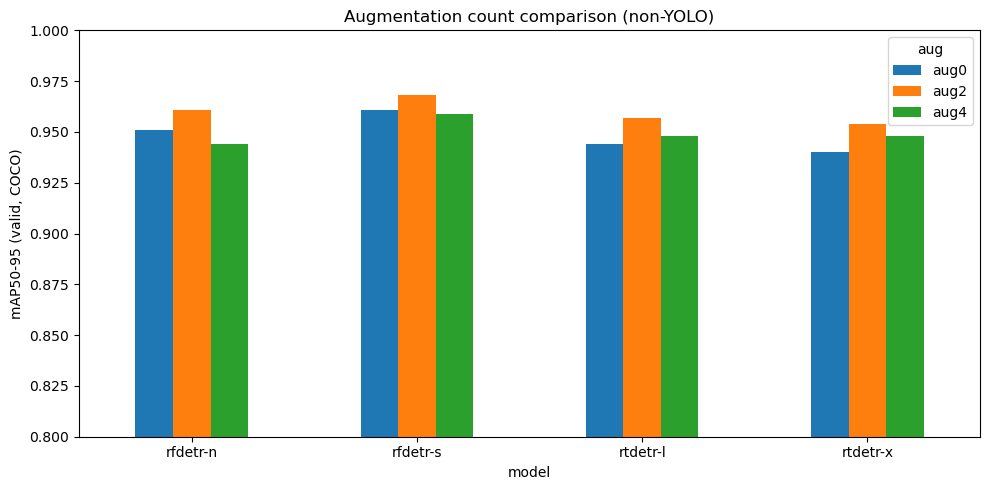

저장: /home/mu-01/ROKEY_mP4_A1/wc/05_non_YOLO_object_detection/result_detection/compare_aug.csv


In [9]:
rows = []
for model_name in MODEL_LIST:
    for aug_name in AUG_SETTINGS:
        run_name = f'{model_name}_{aug_name}'
        print('========== 평가:', run_name)
        rows.append(evaluate(model_name, EXP2_DIR / run_name, model=model_name, aug=aug_name))

# 1) 전체 표
table2 = pd.DataFrame(rows)
display(table2)
table2.to_csv(RESULT_DIR / 'compare_aug.csv', index=False)

# 2) 모델 x 증강 조건 표 (mAP50-95)
pivot = table2.pivot(index='model', columns='aug', values='mAP50-95').reindex(MODEL_LIST)
display(pivot)
pivot.to_csv(RESULT_DIR / 'compare_aug_map.csv')

# 3) 막대 그래프
pivot.plot(kind='bar', figsize=(10, 5), ylim=(0.8, 1.0), rot=0)
plt.ylabel('mAP50-95 (valid, COCO)')
plt.title('Augmentation count comparison (non-YOLO)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'compare_aug_map.png')
plt.show()
print('저장:', RESULT_DIR / 'compare_aug.csv')

## 7. test 이미지 검출 결과 확인
비교 결과를 보고 확인할 모델을 고른 뒤, test 이미지(21장)에 검출 결과(conf 0.25)를 그려 저장한다.
결과: `result_detection/predict_test/<run>/`

[2026-10-06 14:22:36] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-06 14:22:36] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


저장: /home/mu-01/ROKEY_mP4_A1/wc/05_non_YOLO_object_detection/result_detection/predict_test/rfdetr-n_aug2


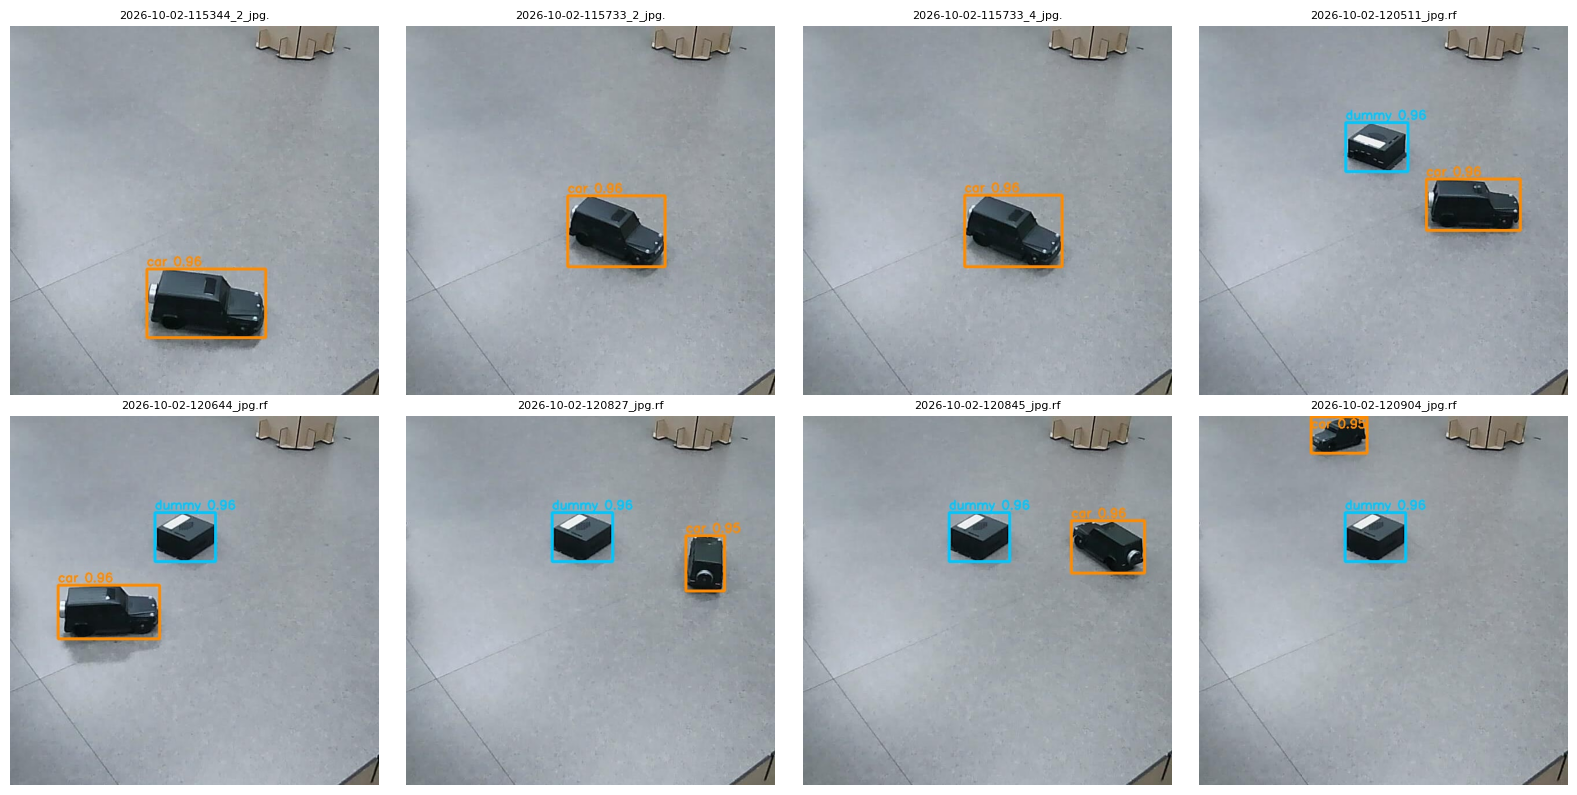

In [10]:
# ⚠️ 확인할 모델 (예: ('rtdetr-l', EXP2_DIR / 'rtdetr-l_aug4'))
CHECK_MODEL, CHECK_RUN = 'rfdetr-n', EXP2_DIR / 'rfdetr-n_aug2'

pred_dir = RESULT_DIR / 'predict_test' / CHECK_RUN.name
pred_dir.mkdir(parents=True, exist_ok=True)
det = Detector(CHECK_MODEL, best_weights(CHECK_MODEL, CHECK_RUN))
for p, bgr in IMAGES['test']:
    img = bgr.copy()
    for c, s, b in det(bgr, CONF_TEST):
        x1, y1, x2, y2 = map(int, b)
        color = (0, 140, 255) if names[c] == 'car' else (255, 200, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img, f'{names[c]} {s:.2f}', (x1, max(y1 - 6, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    cv2.imwrite(str(pred_dir / p.name), img)
del det
free_gpu()
print('저장:', pred_dir)

# 저장된 결과 중 8장 표시
images = sorted(pred_dir.glob('*.jpg'))[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, p in zip(axes.flat, images):
    ax.imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB))
    ax.set_title(p.name[:24], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Test 고정 기준 집계 + 처리 시간 측정 (16개 run + 기준선)
YOLO 실험 8번과 같은 기준이다.
- **Test 집계**: `conf=0.25`, **같은 class의 정답과 IoU≥0.5 일대일 매칭** → class별 TP / FP / FN
  (RT-DETR·YOLO는 NMS `iou=0.7`, RF-DETR은 NMS가 없는 구조라 그대로)
- **처리 시간**: 첫 test 이미지로 5회 워밍업 → test 21장 전체를 3회 반복 (batch 1, 표본 63개).
  모델마다 내부 구간 구분이 달라서 **전처리~후처리 전체 시간(`total_ms`)** 을 같은 방법(GPU 동기화 후 벽시계)으로 잰다.
  Ultralytics 모델(RT-DETR, YOLO26n)은 Ultralytics가 재는 **추론 구간만의 시간(`inf_ms`)** 도 함께 남긴다
- **운용 기준 참고 집계**: 웹캠 node가 쓰는 `conf=0.8`에서 car 미검출(`car_FN_conf08`)과 오검출(`FP_conf08`)
- **mAP**: Val / Test 모두 pycocotools로 같은 코드로 다시 계산(`coco_*`). `val_mAP50_95`는 학습 중 best epoch의 값(각 라이브러리 log)
- **최적 epoch**: 학습 log에서 Val mAP50-95가 처음 최고가 된 epoch. **실제 optimizer**: RT-DETR은 학습 log의 `optimizer:` 줄, RF-DETR은 `training_config.json`

결과: `result_detection/test_eval/` (`final_comparison.csv`, `test_detections.csv`, `speed_samples.csv`, `comparison.png`)

[2026-10-06 14:22:37] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-06 14:22:37] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


log에서 찾은 RT-DETR optimizer 줄: 8 / 8 {'AdamW(lr=0.001667, momentum=0.9)'}


rfdetr-n         best_ep  40 | TP/FP/FN 37/0/0 | test mAP50-95 0.9542 | total 10.544 ms


[2026-10-06 14:22:40] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


...

rtdetr-x_aug0    best_ep  40 | TP/FP/FN 37/0/0 | test mAP50-95 0.9513 | total 30.326 ms


rtdetr-x_aug2    best_ep  59 | TP/FP/FN 37/1/0 | test mAP50-95 0.9416 | total 28.545 ms


rtdetr-x_aug4    best_ep  29 | TP/FP/FN 37/2/0 | test mAP50-95 0.9477 | total 28.575 ms


yolo26n(ref)     best_ep  82 | TP/FP/FN 37/0/0 | test mAP50-95 0.9572 | total 4.993 ms


,exp,model,aug,run,optimizer,best_epoch,last_epoch,train_min,val_mAP50,val_mAP50_95,...,dummy_FP,dummy_FN,car_FN_conf08,FP_conf08,tp_conf_mean,tp_conf_min,total_mean,total_std,total_p95,inf_mean
0,exp1,rfdetr-n,default,rfdetr-n,"AdamW(lr=0.0001, lr_encoder=0.00015)",40,60,12.53,1.0000,0.9587,...,0,0,0,0,0.9591,0.9239,10.544,1.134,13.324,NaN
1,exp1,rfdetr-s,default,rfdetr-s,"AdamW(lr=0.0001, lr_encoder=0.00015)",12,32,9.97,1.0000,0.9551,...,0,0,0,0,0.9477,0.9178,13.316,0.528,14.420,NaN
2,exp1,rtdetr-l,default,rtdetr-l,"AdamW(lr=0.001667, momentum=0.9)",48,68,24.16,0.9943,0.9528,...,0,0,0,0,0.9619,0.9287,19.106,0.940,21.389,17.948
3,exp1,rtdetr-x,default,rtdetr-x,"AdamW(lr=0.001667, momentum=0.9)",18,38,19.48,0.9950,0.9433,...,20,0,0,0,0.9314,0.8959,31.041,2.292,35.653,29.665
4,exp2,rfdetr-n,aug0,rfdetr-n_aug0,"AdamW(lr=0.0001, lr_encoder=0.00015)",20,40,8.14,1.0000,0.9594,...,0,0,0,0,0.9727,0.9420,9.831,0.599,10.723,NaN
5,exp2,rfdetr-n,aug2,rfdetr-n_aug2,"AdamW(lr=0.0001, lr_encoder=0.00015)",18,38,9.47,1.0000,0.9614,...,0,0,0,0,0.9549,0.9185,9.154,0.361,9.758,NaN
6,exp2,rfdetr-n,aug4,rfdetr-n_aug4,"AdamW(lr=0.0001, lr_encoder=0.00015)",23,43,10.07,1.0000,0.9541,...,0,0,0,0,0.9474,0.8771,9.085,0.316,9.641,NaN
7,exp2,rfdetr-s,aug0,rfdetr-s_aug0,"AdamW(lr=0.0001, lr_encoder=0.00015)",21,41,12.13,1.0000,0.9608,...,0,0,0,0,0.9726,0.9580,13.054,0.488,13.833,NaN
8,exp2,rfdetr-s,aug2,rfdetr-s_aug2,"AdamW(lr=0.0001, lr_encoder=0.00015)",77,97,28.54,1.0000,0.9694,...,0,0,0,0,0.9768,0.9563,13.090,0.496,13.745,NaN
9,exp2,rfdetr-s,aug4,rfdetr-s_aug4,"AdamW(lr=0.0001, lr_encoder=0.00015)",66,86,25.54,1.0000,0.9631,...,0,0,0,0,0.9613,0.9344,13.259,0.596,14.433,NaN


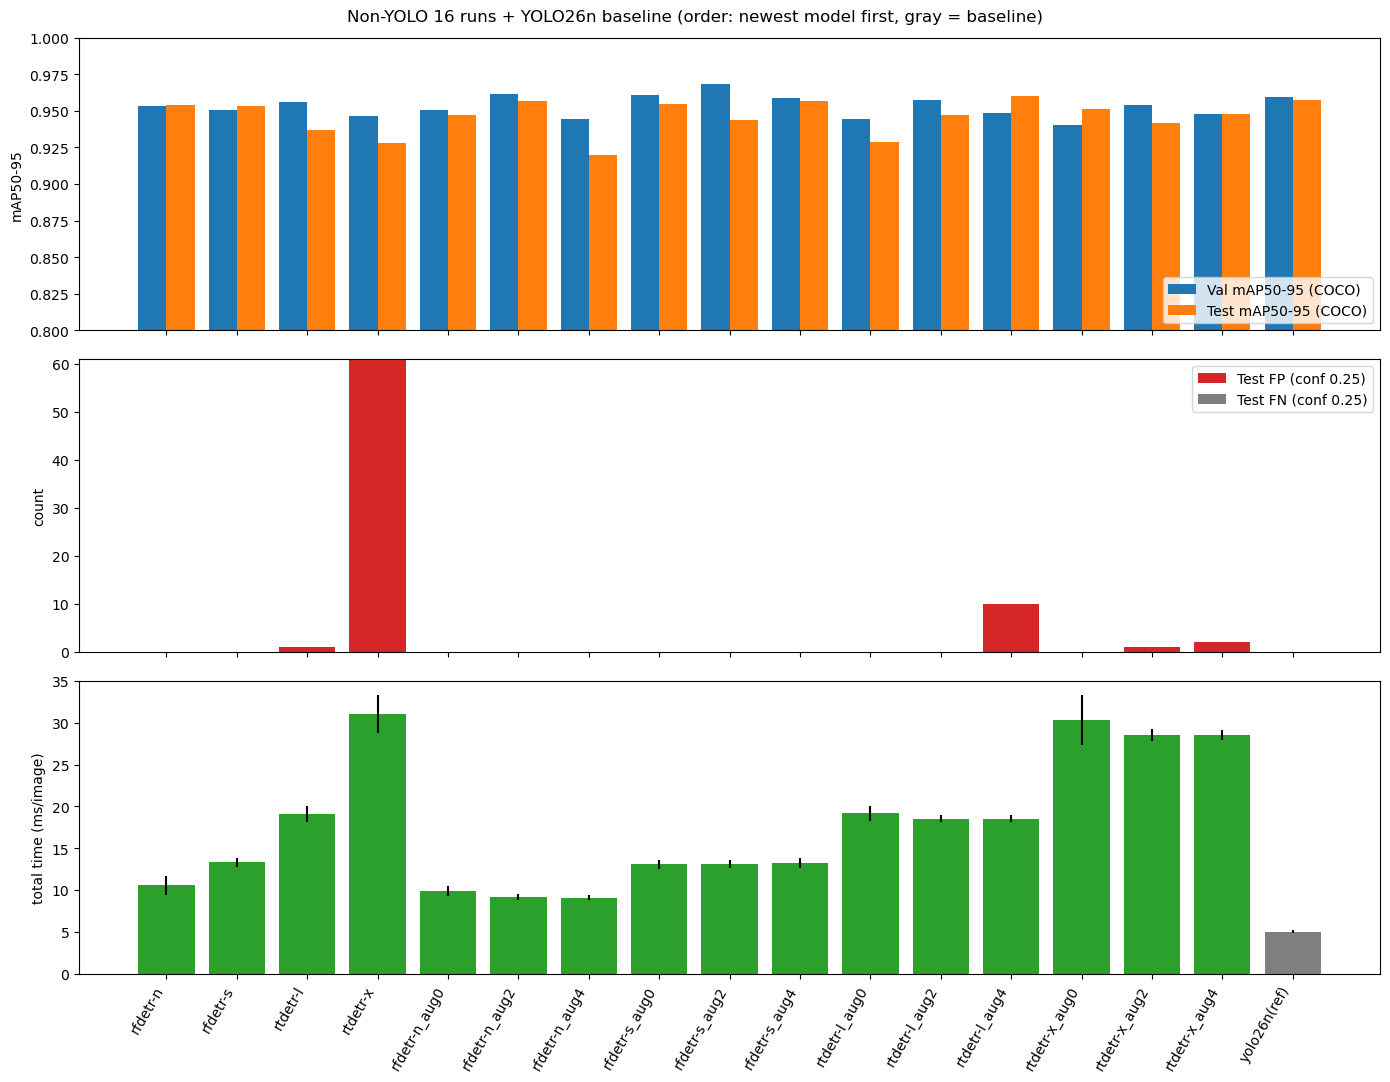

저장: /home/mu-01/ROKEY_mP4_A1/wc/05_non_YOLO_object_detection/result_detection/test_eval


In [11]:
import re

TEST_DIR = RESULT_DIR / 'test_eval'
TEST_DIR.mkdir(exist_ok=True)
OP_CONF = 0.8            # 웹캠 node 운용 conf (참고 집계용)
WARMUP, REPEAT = 5, 3

# 모든 run 목록 (표·그래프 순서: MODEL_LIST 순서, 실험 1 → 실험 2, 마지막에 기준선)
RUNS = [('exp1', m, 'default', EXP1_DIR / m) for m in MODEL_LIST]
RUNS += [('exp2', m, a, EXP2_DIR / f'{m}_{a}') for m in MODEL_LIST for a in AUG_SETTINGS]
RUNS += [('ref', REF_MODEL, 'default', REF_RUN)]

# 학습 log에서 RT-DETR run별 실제 optimizer 읽기 (RT-DETR run 순서대로 'optimizer: ...' 줄이 나온다)
opt_lines = []
for f in sorted(LOG_DIR.glob('log_*.txt')):
    text = re.sub(r'\x1b\[[0-9;]*m', '', f.read_text(encoding='utf-8', errors='ignore'))
    opt_lines += re.findall(r'optimizer: (\w+\(lr=[0-9.]+, momentum=[0-9.]+\))', text)
rt_runs = [r for r in RUNS if r[1].startswith('rtdetr')]
print('log에서 찾은 RT-DETR optimizer 줄:', len(opt_lines), '/', len(rt_runs), set(opt_lines))
rt_opt = dict(zip([r[3].name for r in rt_runs], opt_lines)) if len(opt_lines) == len(rt_runs) else {}


def optimizer_of(model_name, run_dir):
    if is_rfdetr(model_name):
        c = json.loads((run_dir / 'training_config.json').read_text())['train_config']
        return f"AdamW(lr={c['lr']}, lr_encoder={c['lr_encoder']})"
    if model_name == REF_MODEL:
        return 'AdamW(lr=0.001667, momentum=0.9)'   # YOLO 노트북 log에서 확인한 값
    return rt_opt.get(run_dir.name)


summary, det_rows, speed_rows = [], [], []
for exp, model_name, aug, run_dir in RUNS:
    run = run_dir.name if exp != 'ref' else f'{REF_MODEL}(ref)'
    best_ep, last_ep, v50, v95, train_min = history(model_name, run_dir)
    det = Detector(model_name, best_weights(model_name, run_dir))

    # 1) Test 집계 (conf 0.25)
    cnt = {n: dict(gt=0, tp=0, fp=0, fn=0) for n in names}
    tp_conf = []
    for img, bgr in IMAGES['test']:
        h, w = bgr.shape[:2]
        gts = load_gt(img, w, h)
        preds = det(bgr, CONF_TEST)
        tp, used_p, used_g = match(preds, gts)
        tp_iou = {i: iou for i, j, iou in tp}
        for c, _ in gts:
            cnt[names[c]]['gt'] += 1
        for i, (c, cf, b) in enumerate(preds):
            ok = i in used_p
            cnt[names[c]]['tp' if ok else 'fp'] += 1
            if ok:
                tp_conf.append(cf)
            det_rows.append(dict(run=run, image=img.name, cls=names[c], conf=round(cf, 4),
                                 matched=ok, iou=round(tp_iou.get(i, 0.0), 3)))
        for j, (c, b) in enumerate(gts):
            if j not in used_g:
                cnt[names[c]]['fn'] += 1
                det_rows.append(dict(run=run, image=img.name, cls=names[c], conf=None, matched='FN', iou=None))

    # 2) 처리 시간 (워밍업 5회 → 전체 3회 반복)
    for _ in range(WARMUP):
        det.timed(IMAGES['test'][0][1], CONF_TEST)
    for rep in range(REPEAT):
        for img, bgr in IMAGES['test']:
            _, ms = det.timed(bgr, CONF_TEST)
            row = dict(run=run, rep=rep, image=img.name, total_ms=ms)
            if not det.rf:   # Ultralytics가 잰 구간별 시간 (방금 실행한 결과)
                sp = det.last_speed
                row.update(pre_ms=sp['preprocess'], inf_ms=sp['inference'], post_ms=sp['postprocess'])
            speed_rows.append(row)
    sp = pd.DataFrame([s for s in speed_rows if s['run'] == run])

    # 3) Val / Test mAP (pycocotools, 모든 모델 같은 코드)
    cv, _, _, _ = coco_eval(det, 'valid')
    ct, _, _, _ = coco_eval(det, 'test')

    tot = {k: sum(v[k] for v in cnt.values()) for k in ['gt', 'tp', 'fp', 'fn']}
    # 운용 기준 conf 0.8에서의 결과: 0.25 매칭 결과에서 conf 0.8 이상만 남긴다
    d = pd.DataFrame([r for r in det_rows if r['run'] == run])
    d08 = d[d['conf'].notna() & (d['conf'].astype(float) >= OP_CONF)]
    car_tp08 = int(((d08['cls'] == 'car') & (d08['matched'] == True)).sum())
    summary.append(dict(
        exp=exp, model=model_name, aug=aug, run=run, optimizer=optimizer_of(model_name, run_dir),
        best_epoch=best_ep, last_epoch=last_ep, train_min=train_min,
        val_mAP50=round(v50, 4), val_mAP50_95=round(v95, 4),
        coco_val_mAP50=round(cv['mAP50'], 4), coco_val_mAP50_95=round(cv['mAP50_95'], 4),
        coco_test_mAP50=round(ct['mAP50'], 4), coco_test_mAP50_95=round(ct['mAP50_95'], 4),
        test_GT=tot['gt'], test_TP=tot['tp'], test_FP=tot['fp'], test_FN=tot['fn'],
        car_TP=cnt['car']['tp'], car_FP=cnt['car']['fp'], car_FN=cnt['car']['fn'],
        dummy_TP=cnt['dummy']['tp'], dummy_FP=cnt['dummy']['fp'], dummy_FN=cnt['dummy']['fn'],
        car_FN_conf08=cnt['car']['gt'] - car_tp08,
        FP_conf08=int((d08['matched'] == False).sum()),
        tp_conf_mean=round(float(np.mean(tp_conf)), 4) if tp_conf else None,
        tp_conf_min=round(float(np.min(tp_conf)), 4) if tp_conf else None,
        total_mean=round(sp['total_ms'].mean(), 3), total_std=round(sp['total_ms'].std(), 3),
        total_p95=round(sp['total_ms'].quantile(0.95), 3),
        inf_mean=round(sp['inf_ms'].mean(), 3) if 'inf_ms' in sp else None,
    ))
    print(f"{run:16s} best_ep {best_ep:3d} | TP/FP/FN {tot['tp']}/{tot['fp']}/{tot['fn']} | "
          f"test mAP50-95 {ct['mAP50_95']:.4f} | total {summary[-1]['total_mean']} ms")
    del det
    free_gpu()

final = pd.DataFrame(summary)
final.to_csv(TEST_DIR / 'final_comparison.csv', index=False)
pd.DataFrame(det_rows).to_csv(TEST_DIR / 'test_detections.csv', index=False)
pd.DataFrame(speed_rows).to_csv(TEST_DIR / 'speed_samples.csv', index=False)
display(final)

# 비교 그래프: Val / Test mAP50-95, Test 오류 수, 한 장 처리 시간
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
x = np.arange(len(final))
axes[0].bar(x - 0.2, final['coco_val_mAP50_95'], 0.4, label='Val mAP50-95 (COCO)')
axes[0].bar(x + 0.2, final['coco_test_mAP50_95'], 0.4, label='Test mAP50-95 (COCO)')
axes[0].set_ylim(0.8, 1.0); axes[0].legend(loc='lower right'); axes[0].set_ylabel('mAP50-95')
axes[1].bar(x, final['test_FP'], label='Test FP (conf 0.25)', color='tab:red')
axes[1].bar(x, final['test_FN'], bottom=final['test_FP'], label='Test FN (conf 0.25)', color='tab:gray')
axes[1].legend(); axes[1].set_ylabel('count')
axes[2].bar(x, final['total_mean'], yerr=final['total_std'], color=['tab:green'] * (len(final) - 1) + ['tab:gray'])
axes[2].set_ylabel('total time (ms/image)')
axes[2].set_xticks(x); axes[2].set_xticklabels(final['run'], rotation=60, ha='right')
plt.suptitle('Non-YOLO 16 runs + YOLO26n baseline (order: newest model first, gray = baseline)')
plt.tight_layout()
plt.savefig(TEST_DIR / 'comparison.png')
plt.show()
print('저장:', TEST_DIR)

## 9. 선정 모델 상세 분석
위 비교로 고른 모델 1개를 **Validation**으로 다시 평가해서 class별 AP, 혼동행렬, 곡선(PR, F1·P·R-confidence)을 기록한다.
두 계열 모두 같은 코드로 그리기 위해 Ultralytics 그래프 대신 직접 계산한다.
- 혼동행렬: conf 0.25, class 구분 없이 IoU≥0.5로 정답과 예측을 일대일로 짝지은 뒤 (정답 class, 예측 class)를 센다. 짝이 없는 예측은 background 행, 놓친 정답은 background 열
- PR 곡선: pycocotools의 IoU 0.5 precision-recall
- F1 / P / R-confidence 곡선: conf를 0~1로 바꿔 가며 IoU 0.5 일대일 매칭으로 계산
- epoch별 추이(`results.png`): 학습 log(RF-DETR `metrics.csv` / RT-DETR `results.csv`)에서 그림

결과: `result_detection/selected/<run>/` (`per_class_ap.csv`, `results.png`, `validation/`)

[2026-10-06 14:23:34] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-06 14:23:34] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


,class,P,R,AP50,AP50-95
0,car,0.9474,1.0,1.0,0.937
1,dummy,1.0000,1.0,1.0,0.986


Validation 요약 P / R / mAP50 / mAP50-95: 0.9726 1.0 1.0 0.9615


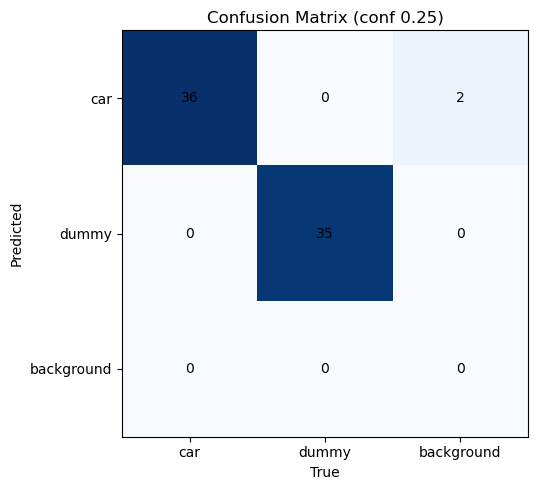

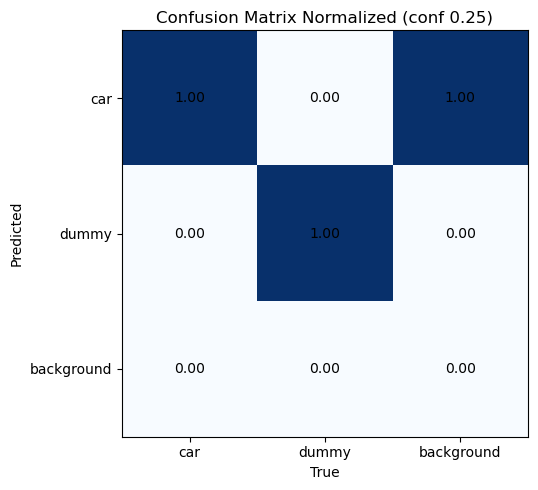

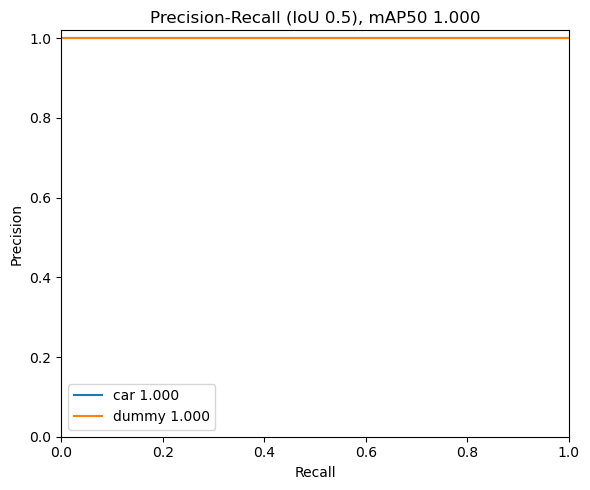

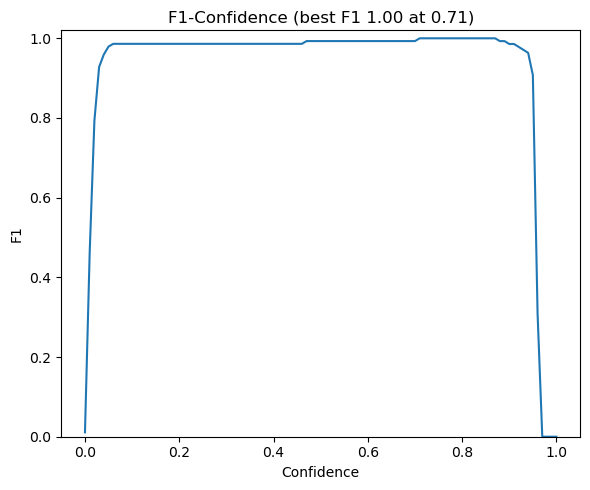

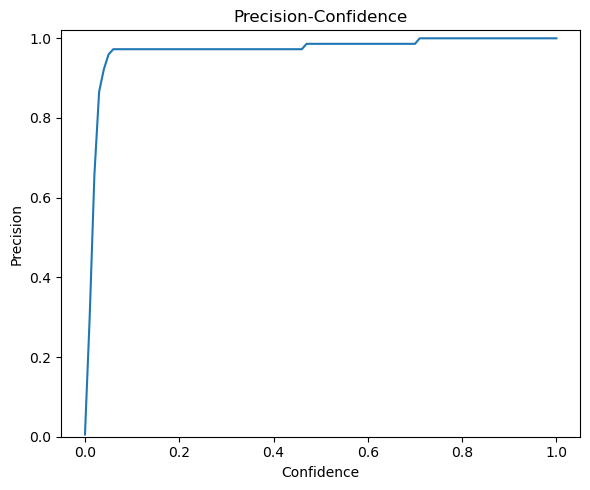

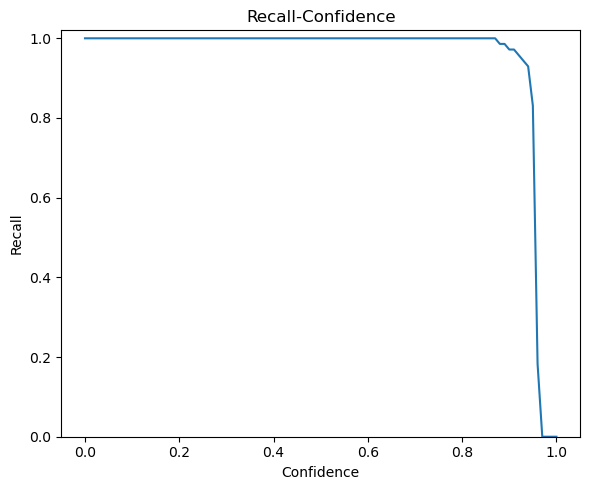

저장: /home/mu-01/ROKEY_mP4_A1/wc/05_non_YOLO_object_detection/result_detection/selected/rfdetr-n_aug2/validation


In [12]:
# ⚠️ 선정 모델 (8번 비교 결과를 보고 정함)
SEL_MODEL, SELECTED_RUN = 'rfdetr-n', EXP2_DIR / 'rfdetr-n_aug2'

SEL_DIR = RESULT_DIR / 'selected' / SELECTED_RUN.name
VAL_DIR = SEL_DIR / 'validation'
VAL_DIR.mkdir(parents=True, exist_ok=True)
det = Detector(SEL_MODEL, best_weights(SEL_MODEL, SELECTED_RUN))
summ, per_class, E, preds_all = coco_eval(det, 'valid')

# 1) class별 AP + conf 0.25 기준 P / R
gt_all = [load_gt(p, bgr.shape[1], bgr.shape[0]) for p, bgr in IMAGES['valid']]
pr = {n: dict(tp=0, fp=0, fn=0) for n in names}
for preds, gts in zip(preds_all, gt_all):
    keep = [x for x in preds if x[1] >= CONF_TEST]
    t, up, ug = match(keep, gts)
    for i, (c, _, _) in enumerate(keep):
        pr[names[c]]['tp' if i in up else 'fp'] += 1
    for j, (c, _) in enumerate(gts):
        if j not in ug:
            pr[names[c]]['fn'] += 1
per_class.insert(1, 'P', [round(pr[n]['tp'] / max(pr[n]['tp'] + pr[n]['fp'], 1), 4) for n in names])
per_class.insert(2, 'R', [round(pr[n]['tp'] / max(pr[n]['tp'] + pr[n]['fn'], 1), 4) for n in names])
display(per_class)
per_class.to_csv(SEL_DIR / 'per_class_ap.csv', index=False)
tp_all = sum(v['tp'] for v in pr.values()); fp_all = sum(v['fp'] for v in pr.values()); fn_all = sum(v['fn'] for v in pr.values())
print('Validation 요약 P / R / mAP50 / mAP50-95:', round(tp_all / max(tp_all + fp_all, 1), 5),
      round(tp_all / max(tp_all + fn_all, 1), 5), round(summ['mAP50'], 5), round(summ['mAP50_95'], 5))

# 2) 혼동행렬 (행: 예측, 열: 정답 — Ultralytics와 같은 방향)
labels = names + ['background']
cm = np.zeros((len(labels), len(labels)), int)
for preds, gts in zip(preds_all, gt_all):
    keep = [x for x in preds if x[1] >= CONF_TEST]
    pairs = sorted(((box_iou(p[2], g[1]), i, j) for i, p in enumerate(keep) for j, g in enumerate(gts)), reverse=True)
    up, ug = set(), set()
    for iou, i, j in pairs:
        if iou < MATCH_IOU:
            break
        if i not in up and j not in ug:
            up.add(i); ug.add(j); cm[keep[i][0], gts[j][0]] += 1
    for i, p in enumerate(keep):
        if i not in up:
            cm[p[0], -1] += 1          # 예측했는데 정답 없음 → background 열(정답=background)
    for j, g in enumerate(gts):
        if j not in ug:
            cm[-1, g[0]] += 1          # 정답을 놓침 → background 행(예측=background)
for norm in [False, True]:
    m = cm / np.maximum(cm.sum(axis=0, keepdims=True), 1) if norm else cm
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(m, cmap='Blues')
    for (r, c), v in np.ndenumerate(m):
        ax.text(c, r, f'{v:.2f}' if norm else int(v), ha='center', va='center')
    ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
    ax.set_xlabel('True'); ax.set_ylabel('Predicted')
    ax.set_title('Confusion Matrix' + (' Normalized' if norm else '') + f' (conf {CONF_TEST})')
    plt.tight_layout()
    plt.savefig(VAL_DIR / ('confusion_matrix_normalized.png' if norm else 'confusion_matrix.png'))
    plt.show()
pd.DataFrame(cm, index=['pred_' + l for l in labels], columns=['true_' + l for l in labels]).to_csv(VAL_DIR / 'confusion_matrix.csv')

# 3) PR 곡선 (IoU 0.5)
rec = np.linspace(0, 1, 101)
fig, ax = plt.subplots(figsize=(6, 5))
for k, n in enumerate(names):
    p50 = E.eval['precision'][0, :, k, 0, -1]
    ax.plot(rec, np.clip(p50, 0, 1), label=f'{n} {per_class.loc[k, "AP50"]:.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_title(f'Precision-Recall (IoU 0.5), mAP50 {summ["mAP50"]:.3f}'); ax.legend()
plt.tight_layout(); plt.savefig(VAL_DIR / 'BoxPR_curve.png'); plt.show()

# 4) F1 / P / R - confidence 곡선 (전체 class)
confs = np.linspace(0, 1, 101)
curve = []
for th in confs:
    tp = fp = fn = 0
    for preds, gts in zip(preds_all, gt_all):
        keep = [x for x in preds if x[1] >= th]
        t, up, ug = match(keep, gts)
        tp += len(t); fp += len(keep) - len(up); fn += len(gts) - len(ug)
    p = tp / (tp + fp) if tp + fp else 1.0
    r = tp / (tp + fn) if tp + fn else 0.0
    curve.append((p, r, 2 * p * r / (p + r) if p + r else 0.0))
curve = np.array(curve)
best_i = int(curve[:, 2].argmax())
for col, name, fname in [(2, 'F1', 'BoxF1_curve.png'), (0, 'Precision', 'BoxP_curve.png'), (1, 'Recall', 'BoxR_curve.png')]:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(confs, curve[:, col])
    ax.set_xlabel('Confidence'); ax.set_ylabel(name); ax.set_ylim(0, 1.02)
    ax.set_title(f'{name}-Confidence' + (f' (best F1 {curve[best_i, 2]:.2f} at {confs[best_i]:.2f})' if col == 2 else ''))
    plt.tight_layout(); plt.savefig(VAL_DIR / fname); plt.show()
pd.DataFrame(dict(conf=confs, P=curve[:, 0], R=curve[:, 1], F1=curve[:, 2])).to_csv(VAL_DIR / 'conf_curve.csv', index=False)
del det
free_gpu()
print('저장:', VAL_DIR)

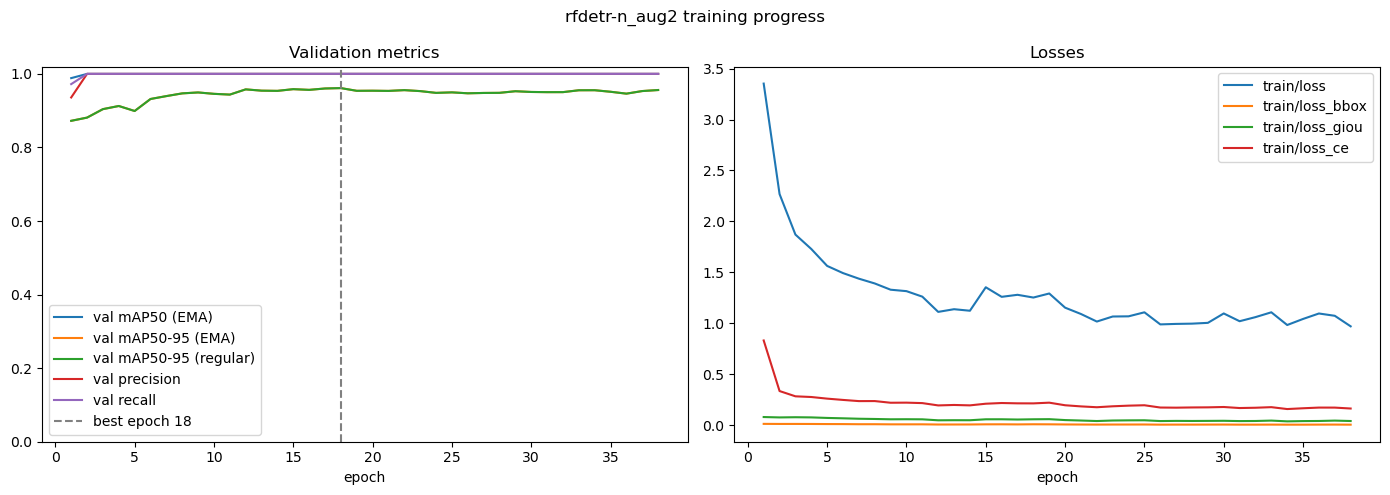

저장: /home/mu-01/ROKEY_mP4_A1/wc/05_non_YOLO_object_detection/result_detection/selected/rfdetr-n_aug2/results.png


In [13]:
# 5) epoch별 학습·검증 추이 (YOLO의 results.png에 해당) — 두 계열 모두 같은 형식으로 그린다
if is_rfdetr(SEL_MODEL):
    h = pd.read_csv(SELECTED_RUN / 'metrics.csv')
    v = h[h['val/mAP_50_95'].notna()].groupby('epoch').last()
    t = h[h['train/loss'].notna()].groupby('epoch').last()
    ep = v.index + 1
    curves = {'val mAP50 (EMA)': v['val/ema_mAP_50'], 'val mAP50-95 (EMA)': v['val/ema_mAP_50_95'],
              'val mAP50-95 (regular)': v['val/mAP_50_95'], 'val precision': v['val/precision'], 'val recall': v['val/recall']}
    losses = {'train/loss': t['train/loss'], 'train/loss_bbox': t['train/loss_bbox'],
              'train/loss_giou': t['train/loss_giou'], 'train/loss_ce': t['train/loss_ce']}
    lep = t.index + 1
else:
    h = pd.read_csv(SELECTED_RUN / 'results.csv')
    ep = lep = h['epoch']
    curves = {'val mAP50': h['metrics/mAP50(B)'], 'val mAP50-95': h['metrics/mAP50-95(B)'],
              'val precision': h['metrics/precision(B)'], 'val recall': h['metrics/recall(B)']}
    losses = {k: h[k] for k in h.columns if k.startswith('train/') or k.startswith('val/')}
best_ep = history(SEL_MODEL, SELECTED_RUN)[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for k, s in curves.items():
    axes[0].plot(ep, s, label=k)
axes[0].axvline(best_ep, color='gray', ls='--', label=f'best epoch {best_ep}')
axes[0].set_xlabel('epoch'); axes[0].set_ylim(0, 1.02); axes[0].legend(); axes[0].set_title('Validation metrics')
for k, s in losses.items():
    axes[1].plot(lep, s, label=k)
axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].set_title('Losses')
plt.suptitle(f'{SELECTED_RUN.name} training progress')
plt.tight_layout()
plt.savefig(SEL_DIR / 'results.png')
plt.show()
print('저장:', SEL_DIR / 'results.png')

## 10. 결과물 위치 정리
```
result_detection/
├── custom_data.yaml          # RT-DETR용 절대 경로 데이터셋 yaml
├── pretrained/               # RT-DETR COCO 사전학습 가중치 (RF-DETR은 ~/.roboflow/models/)
├── log/log_<시각>.txt        # Ultralytics / RF-DETR 학습 log
├── exp1_models/<모델>/        # 실험 1 학습 결과 (RF-DETR: checkpoint_best_total.pth, metrics.csv / RT-DETR: weights/best.pt, results.csv)
├── exp2_aug/<모델>_<조건>/    # 실험 2 학습 결과
├── compare_models.csv / .png # 실험 1 비교표 / 그래프 (기준선 YOLO26n 포함)
├── compare_aug.csv           # 실험 2 전체 비교표
├── compare_aug_map.csv / .png# 실험 2 모델 x 증강 mAP50-95 표 / 그래프
├── predict_test/<run>/       # test 이미지 검출 결과
├── test_eval/                # Test 고정 기준 집계, 처리 시간 (16개 run + 기준선)
└── selected/<run>/validation/# 선정 모델 Validation (혼동행렬, 곡선)
```
`QUICK_TEST = True`로 돌린 결과는 `result_detection/_quick_test/` 아래에 같은 구조로 저장된다.